№1 (3 балла)
1. Создайте объект Series, значениями которого являются целые числа от 1 до 5, а
индексами символы 'a', 'b', 'c', 'd', 'e'.
1. С помощью обращения по явному индексу получите значение 4.
2. С помощью обращения по неявному индексу получите значение 2.
3. Добавьте в серию новый элемент.
4. Используя операцию среза, получите значения 3, 4, 5.
5. Создайте объект DataFrame из списка [[1, 2], [5, 3], [3.7, 4.8]] с именами столбцов
col1 и col2.
6. Используя операцию индексации, получите элемент 3.7.
7. Измените элемент 3 на 9.
8. Используя операцию среза, получите строки с индексами 1 и 2.
9. Добавьте столбец col3, значения которого – результат поэлементного
перемножения col1 и col2.


In [1]:
import pandas as pd

s = pd.Series([1, 2, 3, 4, 5], index=['a', 'b', 'c', 'd', 'e'])
print(s['a'])
print(s.iloc[1])
s['f'] = 6
print(s['f'])
print(s.iloc[2:5:1])
df = pd.DataFrame([[1, 2], [5, 3], [3.7, 4.8]], columns=['col1', 'col2'])
print(df.iloc[2, 0])
df.at[1, 'col2'] = 9
print(df.loc[1:2])
df['col3'] = df['col1'] * df['col2']
print(df)

1
2
6
c    3
d    4
e    5
dtype: int64
3.7
   col1  col2
1   5.0   9.0
2   3.7   4.8
   col1  col2   col3
0   1.0   2.0   2.00
1   5.0   9.0  45.00
2   3.7   4.8  17.76


№2 (4 балла)
Дан список списков data.
data = [["Вжик", "Zipper the Fly", "fly", "0.7"],
["Гайка", "Gadget Hackwrench", "mouse", None],
["Дейл", "Dale", "chipmunk", "1"],
["Рокфор", "Monterey Jack", "mouse", "0.8"],
["Чип", "Chip", "chipmunk", "0.2"]]
На первом месте указывается имя героя на русском (ru_name), затем имя на английском
(en_name), вид героя (class) и индекс веселости, который измеряется в «Дейлах» (cheer).
1. На основе этого списка создайте датафрейм df так, чтобы каждому показателю
(ru_name, en_name, class, cheer) соответствовал один столбец датафрейма.
Проверьте, что последний столбец является числовым. Если нет, приведите его к
типу float.
2. Выведите число строк датафрейма df.
3. Выведите число заполненных (не NaN) ячеек в последнем столбце.
4. Выведите значение в ячейке, которая находится на пересечении третьей строки и
второго столбца.
5. Сохраните в переменную df1 строки датафрейма df со второй по четвертую
включительно и столбцы с первого по третий включительно. Продемонстрируйте
содержимое df1.
6. Присвойте столбцам датафрейма df следующие названия: ru_name, en_name, class,
cheer.
7. Добавьте в датафрейм df столбец logcheer, который содержит логарифмированные
значения cheer (если в cheer встречается NaN, то и в logcheer тоже).
8. Сохраните массив уникальных значений столбца class в переменную x, а
соответствующие им частоты (сколько раз значение встречается в столбце) — в
переменную y. Используя полученные x и y, постройте столбиковую диаграмму,
barplot, для class. Добавьте заголовок и подписи к осям

  ru_name            en_name     class  cheer
0    Вжик     Zipper the Fly       fly    0.7
1   Гайка  Gadget Hackwrench     mouse    NaN
2    Дейл               Dale  chipmunk    1.0
3  Рокфор      Monterey Jack     mouse    0.8
4     Чип               Chip  chipmunk    0.2
ru_name     object
en_name     object
class       object
cheer      float64
dtype: object
5 Число строк
4 Не Nan
Dale На пересечении
df1: //n   ru_name            en_name     class
1   Гайка  Gadget Hackwrench     mouse
2    Дейл               Dale  chipmunk
3  Рокфор      Monterey Jack     mouse
  ru_name            en_name     class  cheer  logcheer
0    Вжик     Zipper the Fly       fly    0.7 -0.356675
1   Гайка  Gadget Hackwrench     mouse    NaN       NaN
2    Дейл               Dale  chipmunk    1.0  0.000000
3  Рокфор      Monterey Jack     mouse    0.8 -0.223144
4     Чип               Chip  chipmunk    0.2 -1.609438
['fly' 'mouse' 'chipmunk'] class
mouse       2
chipmunk    2
fly         1
Name: count, dt

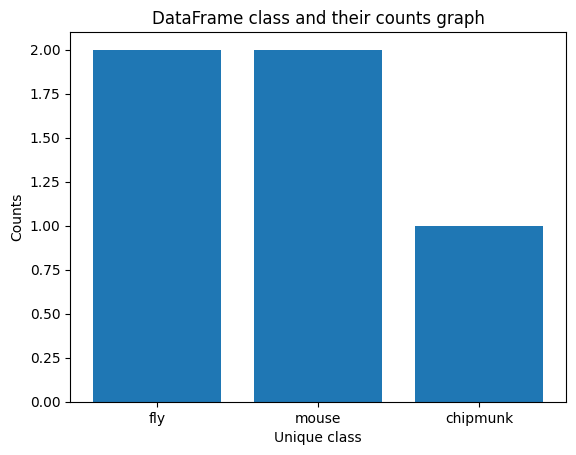

In [ ]:
from matplotlib import pyplot as plt
import numpy
import pandas as pd

data = [["Вжик", "Zipper the Fly", "fly", "0.7"],
["Гайка", "Gadget Hackwrench", "mouse", None],
["Дейл", "Dale", "chipmunk", "1"],
["Рокфор", "Monterey Jack", "mouse", "0.8"],
["Чип", "Chip", "chipmunk", "0.2"]]

df = pd.DataFrame(data, columns=['ru_name', 'en_name', 'class', 'cheer'])
df['cheer'] = pd.to_numeric(df['cheer'])

print(df)
print(df.dtypes)
print(f"{len(df)} Число строк")
print(f"{df.iloc[:, 3].notna().sum()} Не Nan")
print(f"{df.iloc[2, 1]} На пересечении")

df1 = df.iloc[1:4,0:3]
print(df1)
df['logcheer'] = numpy.log(df["cheer"])
print(df)
x = df['class']
y = x.value_counts()
x = x.unique()
print(x, y)
plt.bar(x, y)
plt.title('DataFrame class and their counts graph')
plt.xlabel('Unique class')
plt.ylabel('Counts') 
plt.show()

№3 (4 балла)
Посмотрите информацию о наборе данных о преступности в Лос-Анджелесе
(https://data.lacity.org/Public-Safety/Crime-Data-from-2010-to-2019/63jg-8b9z). Используя
Pandas, выполните следующие действия:
1. Загрузите случайную выборку из этого набора и далее работайте с ней:
https://github.com/slemeshevsky/python-course-ipynb/blob/master/src-pandas/la-crimessample.csv.zip
2. Сколько строк и столбцов в таблице?
3. Каковы названия столбцов? Какие типы данных у столбцов?
4. Сколько в каждом из них уникальных значений?
5. Сколько пропущенных значений?
6. Верно ли, что женщины чаще оказываются жертвами по сравнению с мужчинами?
7. Определите 10 самых распространенных преступлений в Лос-Анджелесе.
Постройте график.
8. От каких преступлений чаще страдают женщины, а от каких мужчины?
9. Люди какого происхождения чаще всего подвергаются преступлениям?
10. Отсортируйте районы, по количеству преступлений. Постройте график,
показывающий самые безопасный и опасный районы.


2. Сколько строк и столбцов в таблице?
39608
27
3. Каковы названия столбцов? Какие типы данных у столбцов?
Index(['Unnamed: 0', 'DR Number', 'Date Reported', 'Date Occurred',
       'Time Occurred', 'Area ID', 'Area Name', 'Reporting District',
       'Crime Code', 'Crime Code Description', 'MO Codes', 'Victim Age',
       'Victim Sex', 'Victim Descent', 'Premise Code', 'Premise Description',
       'Weapon Used Code', 'Weapon Description', 'Status Code',
       'Status Description', 'Crime Code 1', 'Crime Code 2', 'Crime Code 3',
       'Crime Code 4', 'Address', 'Cross Street', 'Location '],
      dtype='object')
Unnamed: 0                  int64
DR Number                   int64
Date Reported              object
Date Occurred              object
Time Occurred               int64
Area ID                     int64
Area Name                  object
Reporting District          int64
Crime Code                  int64
Crime Code Description     object
MO Codes                   object
Vic

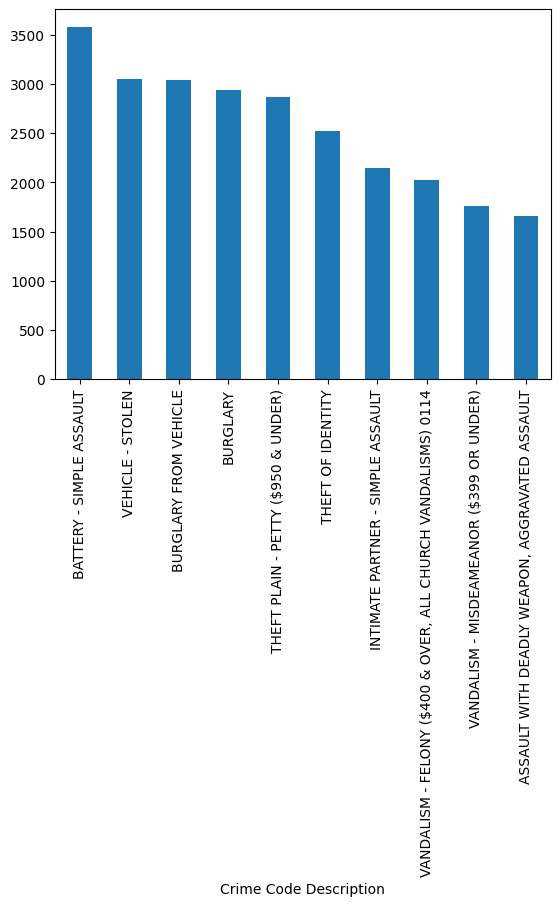

8. От каких преступлений чаще страдают женщины, а от каких мужчины?
Male
Crime Code Description
BATTERY - SIMPLE ASSAULT              1731
BURGLARY FROM VEHICLE                 1665
BURGLARY                              1632
THEFT PLAIN - PETTY ($950 & UNDER)    1499
THEFT OF IDENTITY                     1262
Name: count, dtype: int64
Female
Crime Code Description
BATTERY - SIMPLE ASSAULT              1838
INTIMATE PARTNER - SIMPLE ASSAULT     1764
BURGLARY FROM VEHICLE                 1361
THEFT PLAIN - PETTY ($950 & UNDER)    1294
THEFT OF IDENTITY                     1251
Name: count, dtype: int64
9. Люди какого происхождения чаще всего подвергаются преступлениям?
Victim Descent
H    13488
Name: count, dtype: int64
10. Отсортируйте районы, по количеству преступлений. Постройте график,показывающий самые безопасный и опасный районы.


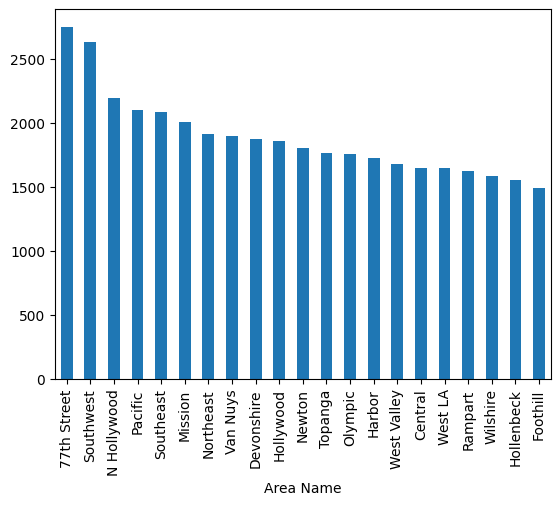

In [7]:
from matplotlib import pyplot as plt
import pandas as pd


df = pd.read_csv('la-crimes-sample.csv')

print("2. Сколько строк и столбцов в таблице?")

print(len(df))
print(len(df.columns))

print("3. Каковы названия столбцов? Какие типы данных у столбцов?")

print(df.columns)
print(df.dtypes)

print("4. Сколько в каждом из них уникальных значений?")

for column in df.columns:
    temp = df[column]
    print(temp.nunique())

print("5. Сколько пропущенных значений?")

for col_index in range(len(df.columns)):
    print(df.iloc[:, col_index].isna().sum())

print("6. Верно ли, что женщины чаще оказываются жертвами по сравнению с мужчинами?")

x = df['Victim Sex']
male_crime_victims = len(df[df['Victim Sex'] == 'M'])
female_crime_victims = len(df[df['Victim Sex'] == 'F'])
if female_crime_victims > male_crime_victims:
    print(True)
else: 
    print(False)
print(male_crime_victims, female_crime_victims)

print("7. Определите 10 самых распространенных преступлений в Лос-Анджелесе. Постройте график.")

crimes = df['Crime Code Description'].value_counts().head(10)
crimes.plot(kind='bar')
plt.show()

print("8. От каких преступлений чаще страдают женщины, а от каких мужчины?")

print('Male')
filtered_male = df[df['Victim Sex'] == 'M']
print(filtered_male['Crime Code Description'].value_counts().head(5))

print('Female')
filtered_female = df[df['Victim Sex'] == 'F']
print(filtered_female['Crime Code Description'].value_counts().head(5))

print("9. Люди какого происхождения чаще всего подвергаются преступлениям?")

print(df['Victim Descent'].value_counts().head(1))
print("10. Отсортируйте районы, по количеству преступлений. Постройте график,показывающий самые безопасный и опасный районы.")

area_counts = df['Area Name'].value_counts()
area_counts.plot(kind='bar')
plt.show()

№4 (4 балла)
В файле polit.csv (https://cloud.mail.ru/public/P5P7/qjm2F8CuN) хранятся некоторые данные,
используемые в исследовании James W.McGuire, “Authoritarianism in the Middle East”.
Показатели:
 ctry – страна;
 fh09 – индекс Freedom House за 2009 год (от 1 до 7, большие значения соответствуют
меньшему уровню гражданских свобод);
 polity09 – индекс Polity2 за 2009 год (от -10 до 10, большие значения соответствуют
большему уровню демократии);
 gini – индекс Джини за 2000-2010 годы (индекс имущественного неравенства);
 fparl08 – доля женщин в парламенте в 2008 году (в процентах);
 mena – регион Middle East and North Africa (1 – да, 0 – нет);
 lati – регион Latin America;
 cari – регион Caribbean, former British, French, Dutch colony;
 east – регион East Asia;
 sovi – регион Former Soviet Bloc;
 afri – регион Africa;
 corr0509 – индекс Control of Corruption, среднее за 2005-2009 годы.
Выполните следующие задания:
1. Загрузите датафрейм из файла polit.csv и сохраните его в переменную polit. Если в
датафрейме есть строки с пропущенными значениями, то удалите их.
2. Выберите в датафрейме строки, которые соответствуют странам со значениями
индекса Freedom House (fh09) выше 5.
3. Выберите в датафрейме строки, которые соответствуют странам Африки (afri) с
процентом женщин в парламенте (fparl08) выше 30%.
4. Выберите в датафрейме строки, которые соответствуют странам Африки или
Латинской Америки (afri и lati) со значением индекса Polity2 (polity09) больше или
равным 8.
5. Добавьте в датафрейм polit столбец corr_round, в котором будут храниться
округленные до 2 знака после запятой значения индекса Control of Corruption
(corr0509).
6. Добавьте в датафрейм polit столбец fh_status, в котором будут храниться типы стран
в зависимости от значения индекса Freedom House (значения free, partly free, not free).
Соответствие значений fh09 с типами стран см. здесь
https://freedomhouse.org/sites/default/files/2020-02/Methodology_FIW_2016.pdf (Table
3 на последней странице).
7. Сгруппируйте строки в таблице в соответствии со значениями столбца fh_status,
полученного в предыдущей части и выведите минимальное, среднее и максимальное
значение показателя gini (индекс Джини) по каждой группе.
8. Сгруппируйте строки в таблице в соответствии со значениями столбца fh_status и
запишите строки, относящиеся к разным группам, в отдельные csv-файлы.


In [10]:
import pandas as pd

print("1. Загрузите датафрейм из файла polit.csv и сохраните его в переменную polit. Если в датафрейме есть строки с пропущенными значениями, то удалите их.")
polit = pd.read_csv('polit.csv', decimal=",")
polit = polit.drop(columns=["Unnamed: 13"])
polit = polit.dropna()

print(polit)

print("2. Выберите в датафрейме строки, которые соответствуют странам со значениями индекса Freedom House (fh09) выше 5.")
polit['fh09'] = pd.to_numeric(polit['fh09'])
fh_more_than_5 = polit[polit['fh09'] > 5]

print(fh_more_than_5)

print("3. Выберите в датафрейме строки, которые соответствуют странам Африки (afri) с процентом женщин в парламенте (fparl08) выше 30%.")
afr_fparl = polit[(polit['afri'] == 1) & (polit['fparl08'] > 30)]
print(afr_fparl)

print("4. Выберите в датафрейме строки, которые соответствуют странам Африки или Латинской Америки (afri и lati) со значением индекса Polity2 (polity09) больше или равным 8.")
africa_latin_polit = polit[((polit['afri'] == 1) | (polit['lati'] == 1)) & (polit['polity09'] >= 8)]
print(africa_latin_polit)

print("5. Добавьте в датафрейм polit столбец corr_round, в котором будут хранитьсяокругленные до 2 знака после запятой значения индекса Control of Corruption(corr0509).")
polit['corr_round'] = polit["corr0509"].round(2)

print("6. Добавьте в датафрейм polit столбец fh_status, в котором будут храниться типы стран в зависимости от значения индекса Freedom House (значения free, partly free, not free). Соответствие значений fh09 с типами стран см. здесь")
nums = [0, 2.5, 5.0, 7.0]
labels = ["Free", "Partly Free", "Not Free"]
polit['fh_status'] = pd.cut(polit['fh09'], bins=nums, labels=labels, include_lowest=True)
print(polit)

print("7. Сгруппируйте строки в таблице в соответствии со значениями столбца fh_status,полученного в предыдущей части и выведите минимальное, среднее и максимальное значение показателя gini (индекс Джини) по каждой группе.")
ginn = polit.groupby('fh_status')['gini'].agg(['min', 'mean', 'max'])
print(ginn)

print("8. Сгруппируйте строки в таблице в соответствии со значениями столбца fh_status и запишите строки, относящиеся к разным группам, в отдельные csv-файлы.")
for fhstatus, group in polit.groupby('fh_status'):
    filename = f"{fhstatus}.csv"
    group.to_csv(filename)

1. Загрузите датафрейм из файла polit.csv и сохраните его в переменную polit. Если в датафрейме есть строки с пропущенными значениями, то удалите их.
     Unnamed: 0           ctry  fh09  polity09  gini  fparl08  mena  lati  \
1             1        Albania   3.0       9.0  33.0     7.14     0     0   
2             2        Algeria   5.5       2.0  35.3     6.48     1     0   
5             5         Angola   5.5      -2.0  58.6    37.27     0     0   
7             7      Argentina   2.0       8.0  48.8    39.76     0     1   
8             8        Armenia   5.0       5.0  30.2     8.40     0     0   
..          ...            ...   ...       ...   ...      ...   ...   ...   
206         206  Venezuela, RB   4.5      -3.0  43.4    18.56     0     1   
207         207        Vietnam   6.0      -7.0  37.8    25.76     0     0   
210         210    Yemen, Rep.   5.5      -2.0  37.7     0.73     1     0   
211         211         Zambia   3.5       7.0  50.7    15.19     0     0   
212

C:\Users\Norrim\AppData\Local\Temp\ipykernel_320984\553898752.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ginn = polit.groupby('fh_status')['gini'].agg(['min', 'mean', 'max'])
C:\Users\Norrim\AppData\Local\Temp\ipykernel_320984\553898752.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for fhstatus, group in polit.groupby('fh_status'):


№5 (4 балла)
Используя набор данных Video Game Sales https://www.kaggle.com/gregorut/videogamesales:
1. Вывести все доступные платформы, на которых выпускалась хотя-бы одна игра;
2. Добавить к копии набора данных столбец metacritic_rating и заполнить его данными
из набора данных Metacritic all time games stats
(https://www.kaggle.com/skateddu/metacritic-all-time-games-stats);
3. Вывести список игр, рейтинг которых равен "M" и год издания не ранее 2012 года;
4. Рассчитать и вывести описательные статистики для списка, полученного в
предыдущем пункте;
5. Вывести жанры игр с количеством игр, которые принадлежат соответствующему
жанру в виде "<жанр> - <количество игр>" для всех жанров, которые содержат в
своем названии не менее 3 различных гласных.

In [ ]:
import pandas as pd

games = pd.read_csv('vgsales.csv')
metacritic = pd.read_csv("metacritic_games.csv")

print("1. Вывести все доступные платформы, на которых выпускалась хотя-бы одна игра")
print(games['Platform'].unique())
games_copy = games.copy()

print("2. Добавить к копии набора данных столбец metacritic_rating и заполнить его данными из набора данных Metacritic all time games stats")
games_copy = games_copy.merge(
    right=metacritic[['name', 'rating']],
    how='left',
    left_on='Name',
    right_on='name'
)

print(games_copy)

print("3. Вывести список игр, рейтинг которых равен M и год издания не ранее 2012 года;")
games_m = games_copy[(games_copy['rating'] == 'M') & (games_copy['Year'] >= 2012)]
print(games_m)